# Group J - Problem Set 2

## Queueing Theory Simulations

In [15]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import random
import math
import pandas as pd

## a) Arrival and Service Rate Estimates

We take our estimates for the 5-minute intervals, and divide by 5 to get 1-minute estimates. These are averaged to find estimates for the arrival and service rates per minute.

In [ ]:
# data
arrival_nums = np.array([12, 12, 13, 11, 14, 12, 13, 15, 11, 13]) * 1/5
service_nums = np.array([15, 10, 17, 14, 13, 16, 12, 15, 14, 14]) * 1/5

arrival_rate_est = sum(arrival_nums)/len(arrival_nums)
service_rate_est = sum(service_nums)/len(service_nums)

print(f"Average Arrival Rate (per minute): {round(arrival_rate_est, 3)}")
print(f"Average Service Rate (per minute): {round(service_rate_est, 3)}")

Average Arrival Rate (per minute): 2.52
Average Service Rate (per minute): 2.8


### Visualisations of Samples

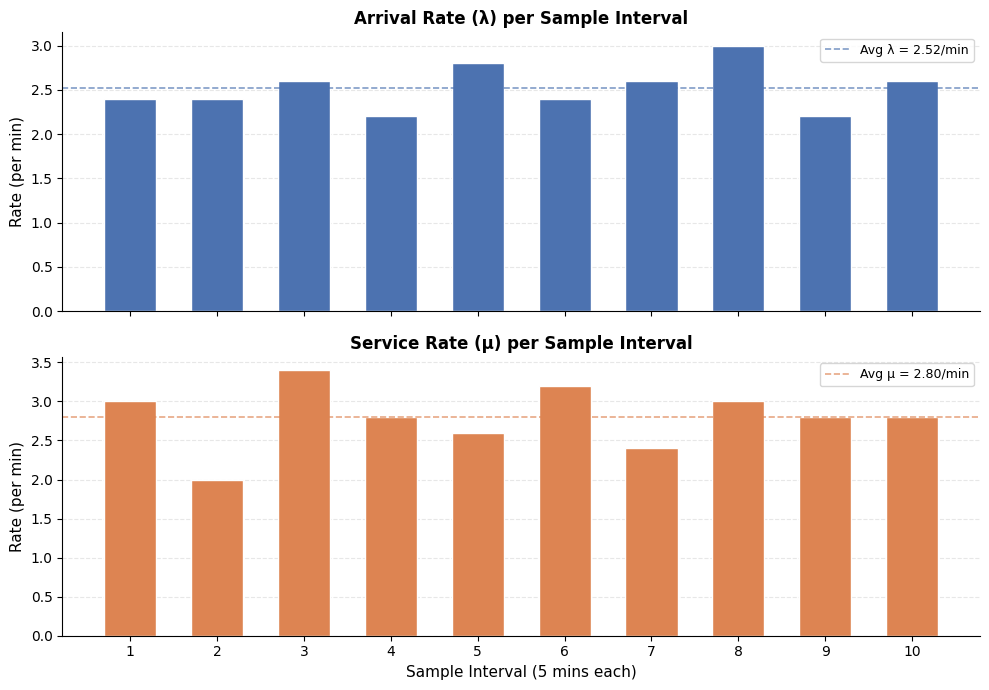

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

x = np.arange(1, len(arrival_nums) + 1)

# Arrival rates
ax1.bar(x, arrival_nums, color='#4C72B0', edgecolor='white', width=0.6)
ax1.axhline(y=arrival_rate_est, color='#4C72B0', linestyle='--', linewidth=1.2, alpha=0.7,
            label=f'Avg λ = {arrival_rate_est:.2f}/min')
ax1.set_ylabel('Rate (per min)', fontsize=11)
ax1.set_title('Arrival Rate (λ) per Sample Interval', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_axisbelow(True)
ax1.yaxis.grid(True, linestyle='--', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Service rates
ax2.bar(x, service_nums, color='#DD8452', edgecolor='white', width=0.6)
ax2.axhline(y=service_rate_est, color='#DD8452', linestyle='--', linewidth=1.2, alpha=0.7,
            label=f'Avg μ = {service_rate_est:.2f}/min')
ax2.set_xlabel('Sample Interval (5 mins each)', fontsize=11)
ax2.set_ylabel('Rate (per min)', fontsize=11)
ax2.set_title('Service Rate (μ) per Sample Interval', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.legend(fontsize=9)
ax2.set_axisbelow(True)
ax2.yaxis.grid(True, linestyle='--', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## b) M/M/1 Queue Simulation

As per tutorial 10, we use the inverse-transform sampling method for the exponential distribution. The generate_samples() function generates a vector of d random numbers using this exponential_sample() function, with the lamda parameter being our estimated rate for arrival or service.

In [18]:
# inverse-transform sampling for random numbers:
def exponential_sample(lamda):
    r = random.random()
    return -math.log(r) / lamda

def generate_samples(d):
    samples_interarrival = [exponential_sample(arrival_rate_est) for _ in range(d)]
    samples_service = [exponential_sample(service_rate_est) for _ in range(d)]
    return samples_interarrival, samples_service

Again using the logic from tutorial 10, we define the Lindley Recursion Equation, which calculates the waiting time for a customer using the recursion that a customer either waits no time (if there is no customer in front of them being served), or waits for a time equal to the total time of the person in front of them in the system (the customer before them's waiting and service times) minus the time that the current customer was NOT YET in the system for (the interarrival time between the customer in front and current customer).

In [19]:
# set up recursion function using Lindley's equation
def recurse_lindley(service_times, interarrival_times, d):
    
    waiting_times = [0]*d
    for i in range(d-1):
        waiting_times[i+1] = max(0, waiting_times[i] + service_times[i] - interarrival_times[i])
    time_in_system = [waiting_times[i] + service_times[i] for i in range(d)]

    avg_wait_queue = sum(waiting_times) / d
    avg_system_time = sum(time_in_system) / d
    return waiting_times

We take the service, interarrival and waiting times, and use them to create a time-ordered list of discrete "events", where an event is defined as a customer entering the system, or leaving it (after being served). Thus, an event is defined as a tuple (timestamp, change) where timestamp is the time the event occurred, and change is +1 for a new customer entering the system, and -1 for a customer leaving the system. This is similar to the logic employed in tutorial 10. This will be used to track the queue length evolving dynamically.

The report_estimates() function takes the computed waiting times and events lists, and calculates empirically the average queue length over time (i.e. a weighted sum of the queue length in an interval, with weights being the time length of the interval), average waiting time (sum of weighting dimes / number of customers (d)), and average server utilisation ratio (i.e. the proportion of the total time the queue length was greater than 0, and thus the server was occupied). 

In [20]:
# record events (when customers enter or leave)
def record_events(service_times, interarrival_times, waiting_times, d):

    # generate events tracker
    arrival_times = [0]*d
    for i in range(1,d):
        arrival_times[i] = arrival_times[i-1] + interarrival_times[i-1]
    service_start_times = [arrival_times[i] + waiting_times[i] for i in range(d)]
    service_end_times = [service_start_times[i] + service_times[i] for i in range(d)]
    events = []
    for time in arrival_times:
        events.append((time, +1))
    for time in service_end_times:
        events.append((time, -1))
    events.sort()

    return events

# report required estimates from simulation run
def report_estimates(waiting_times, events, d):

    # i) estimate average queue length + iii) utilisation ratio
    time_server_occupied = 0
    previous_time = 0
    time_weighted_total_L = 0
    current_L = 0
    for time, change_L in events:
        time_delta = time - previous_time
        if current_L > 0:
            time_server_occupied += time_delta
        time_weighted_total_L += current_L * time_delta
        previous_time = time
        current_L += change_L
    average_L = time_weighted_total_L / previous_time
    utilisation_ratio = time_server_occupied / previous_time
    
    # ii) estimate average wait time
    average_wait = sum(waiting_times) / d

    return np.array([average_L, average_wait, utilisation_ratio])
    

We then compute the theoretical values we expect based on M/M/1 theory to compare with our Monte Carlo estimates. 

The system utilization ($\rho$) is calculated as:
$$\rho = \frac{\lambda}{\mu}$$

The expected number of customers in the system ($L$) is:
$$L = \frac{\rho}{1 - \rho}$$

The expected waiting time in the queue ($W_q$) is:
$$W_q = \frac{\rho}{\mu - \lambda}$$

Where:
* $\lambda$ = `arrival_rate_est`
* $\mu$ = `service_rate_est`

In [21]:
# calculate theoretical values:
rho = arrival_rate_est / service_rate_est
expected_L = rho / (1 - rho)
expected_wait = rho / (service_rate_est - arrival_rate_est)

The below cell is simply the main control loop - it decides that we do 50 Monte Carlo runs, each with 1,000,000 draws (or customers) to attempt to estimate the parameter values desired. Such a high d is demanded by the fact that our lambda and mu are similar values. The before-defined functions are called in order, and the 50 run estimates are averaged to give an overall estimate. These are reported along with the error with respect to the theoretical values expected, 95% confidence intervals and coverage. Sub-1% errors and 95% coverage is observed for all 3 desired moments.

In [22]:
n = 50
d = 1000000

estimates_list = []

for run in range(n):
    random.seed(run)
    samples_interarrival, samples_service = generate_samples(d)
    waiting_times = recurse_lindley(samples_service, samples_interarrival, d)
    events = record_events(samples_service, samples_interarrival, waiting_times, d)
    estimates = report_estimates(waiting_times, events, d)
    estimates_list.append(estimates)

estimates_array = np.array(estimates_list)
means = estimates_array.mean(axis=0)
stds = estimates_array.std(axis=0, ddof=1)
ci95 = 1.96 * stds / np.sqrt(n)

estimate_L, estimate_wait, estimate_utilisation_ratio = means
ci_L, ci_wait, ci_util = ci95
rho = arrival_rate_est / service_rate_est
expected_L = rho / (1 - rho)
expected_wait = rho / (service_rate_est - arrival_rate_est)

data = {
    "Metric": ["Queue Length (L)", "Waiting Time (mins)", "Utilisation Ratio"],
    "Theoretical": [expected_L, expected_wait, rho],
    "Monte Carlo Estimate": means,
    "95% CI (±)": ci95,
    "% Error": np.abs(means - [expected_L, expected_wait, rho]) / [expected_L, expected_wait, rho] * 100,
    "Coverage": [
        "Yes" if abs(means[0] - expected_L) <= ci_L else "No",
        "Yes" if abs(means[1] - expected_wait) <= ci_wait else "No",
        "Yes" if abs(means[2] - rho) <= ci_util else "No"
    ]
}

df = pd.DataFrame(data)
df[["Theoretical", "Monte Carlo Estimate"]] = df[["Theoretical", "Monte Carlo Estimate"]].round(4)
df["95% CI (±)"] = df["95% CI (±)"].round(4)
df["% Error"] = df["% Error"].round(3)

print("=== M/M/1 Queue: Theoretical vs Monte Carlo Estimates ===\n")
print(df.to_string(index=False))

=== M/M/1 Queue: Theoretical vs Monte Carlo Estimates ===

             Metric  Theoretical  Monte Carlo Estimate  95% CI (±)  % Error Coverage
   Queue Length (L)       9.0000                8.9863      0.0429    0.152      Yes
Waiting Time (mins)       3.2143                3.2089      0.0166    0.167      Yes
  Utilisation Ratio       0.9000                0.9000      0.0003    0.005      Yes


### Visualisations for M/M/1 Queue Simulation

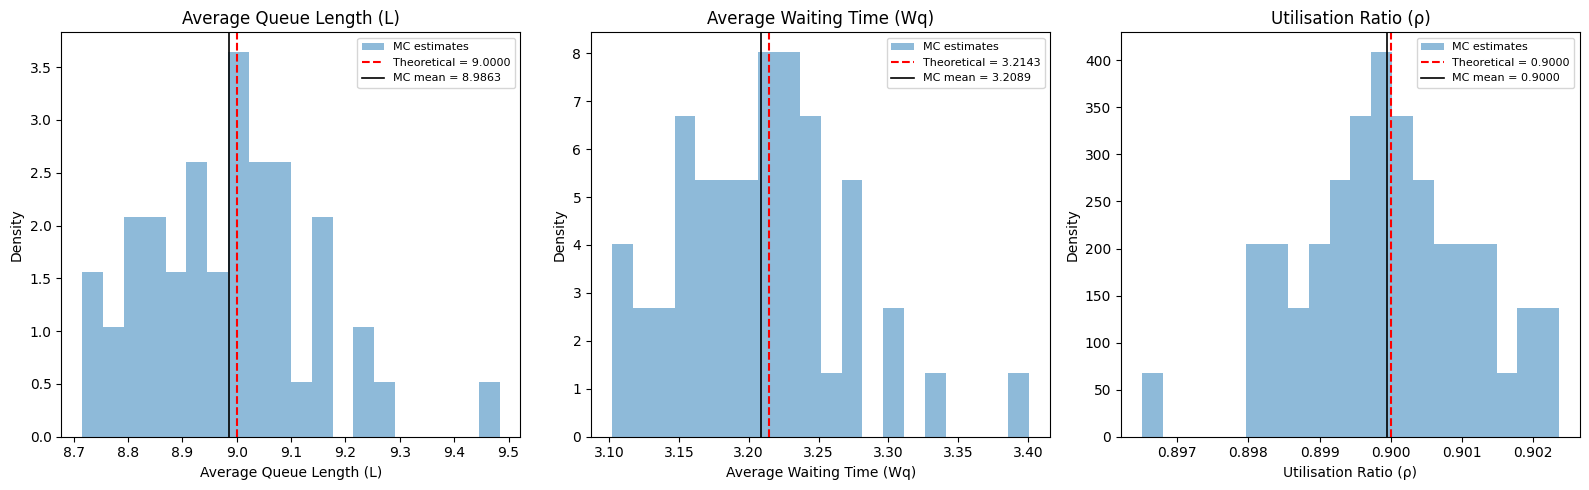

In [23]:
# Distribution of estimates across 50 Monte Carlo runs
plt.figure(figsize=(16, 5))

titles = ["Average Queue Length (L)", "Average Waiting Time (Wq)", "Utilisation Ratio (ρ)"]
theoretical = [expected_L, expected_wait, rho]

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.hist(estimates_array[:, i], bins=20, density=True, alpha=0.5, label="MC estimates")
    plt.axvline(theoretical[i], color='r', linestyle='--', linewidth=1.5,
                label=f"Theoretical = {theoretical[i]:.4f}")
    plt.axvline(means[i], color='black', linestyle='-', linewidth=1.2,
                label=f"MC mean = {means[i]:.4f}")
    plt.xlabel(titles[i])
    plt.ylabel("Density")
    plt.title(titles[i])
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

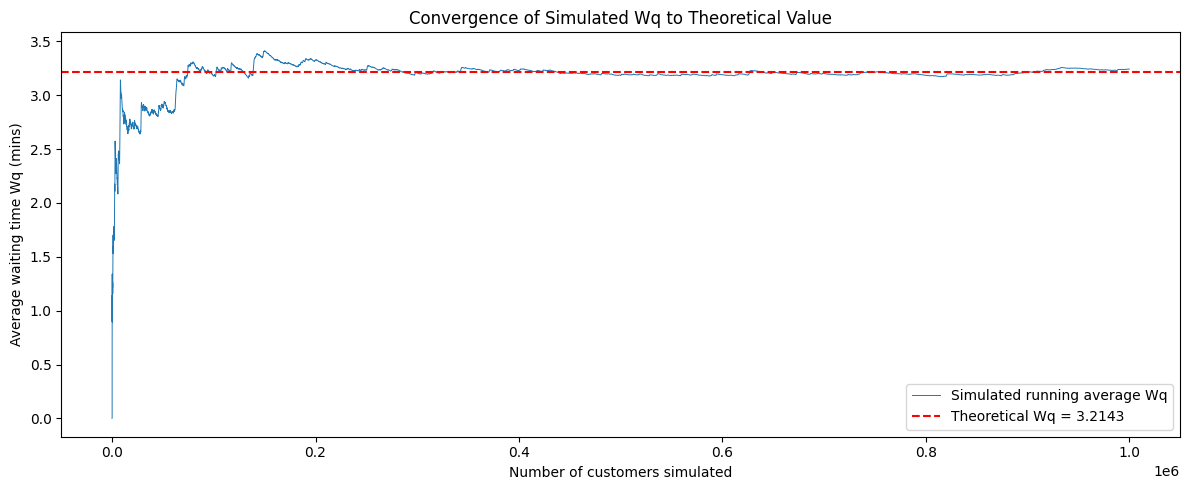

In [24]:
# Convergence of running average waiting time
random.seed(38)
samples_interarrival, samples_service = generate_samples(d)
waiting_times_conv = recurse_lindley(samples_service, samples_interarrival, d)

running_avg = np.cumsum(waiting_times_conv) / np.arange(1, d + 1)

plt.figure(figsize=(12, 5))
plt.plot(range(1, d + 1), running_avg, linewidth=0.7, label="Simulated running average Wq")
plt.axhline(y=expected_wait, color='r', linestyle='--', linewidth=1.5,
            label=f"Theoretical Wq = {expected_wait:.4f}")
plt.xlabel("Number of customers simulated")
plt.ylabel("Average waiting time Wq (mins)")
plt.title("Convergence of Simulated Wq to Theoretical Value")
plt.legend()
plt.tight_layout()
plt.show()

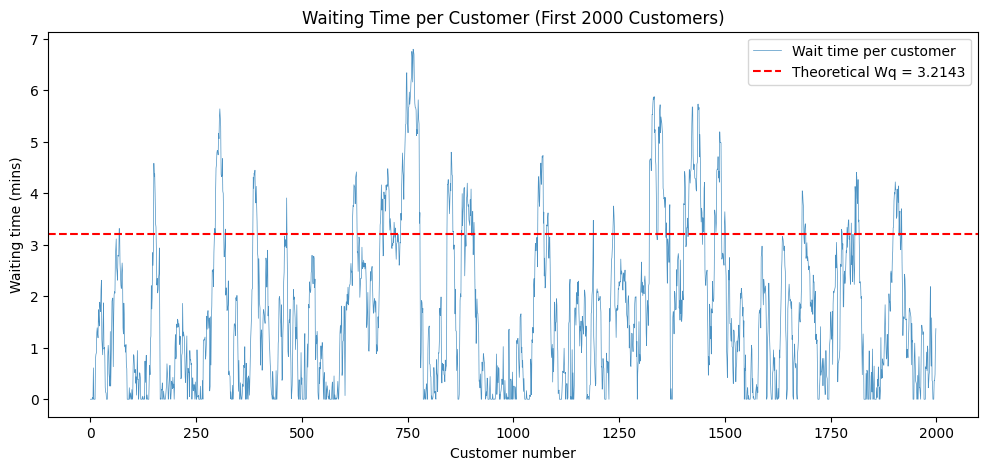

In [25]:
# Waiting time per customer (first 2000 from previous run)
plt.figure(figsize=(12, 5))
plt.plot(range(2000), waiting_times_conv[:2000], linewidth=0.5, alpha=0.8, label="Wait time per customer")
plt.axhline(y=expected_wait, color='r', linestyle='--', linewidth=1.5,
            label=f"Theoretical Wq = {expected_wait:.4f}")
plt.xlabel("Customer number")
plt.ylabel("Waiting time (mins)")
plt.title("Waiting Time per Customer (First 2000 Customers)")
plt.legend()
plt.show()